This visualization represents a 3D intensity surface generated from astronomical image data. Each pixel in the image is mapped onto a spatial coordinate system (x,y), while the pixel brightness value is used as the height coordinate z. Mathematically, the image can be described as a two-dimensional intensity function I(x,y), visualized as a surface where peaks correspond to regions of high photon flux and valleys correspond to low-intensity regions. Bright stars appear as sharp Gaussian-like peaks, while extended objects such as galaxies form broader intensity distributions. This representation allows the underlying structure, brightness gradients, and spatial distribution of astronomical sources to be examined more effectively than in a standard 2D image.

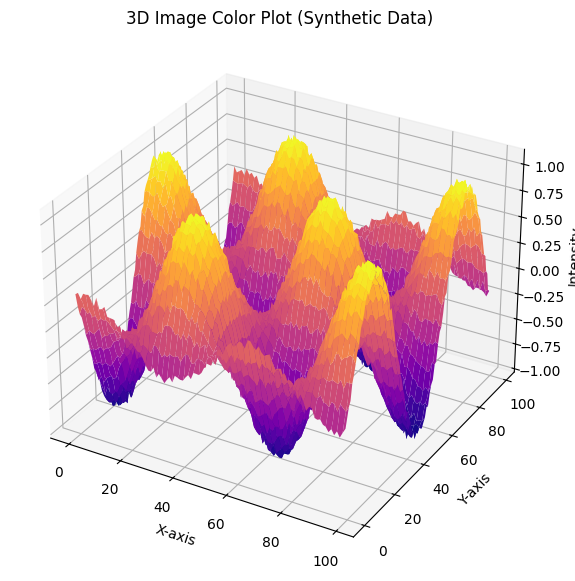

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Simulate 2D image data for demonstration since 'image.fits' was not found
# In a real scenario, you would upload your 'image.fits' file and use:
# data = fits.getdata("image.fits")

# Create some sample data (e.g., a 2D Gaussian or a sine wave pattern)
x_grid, y_grid = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
data = np.sin(x_grid) * np.cos(y_grid) + np.random.rand(100, 100) * 0.1 # Example data

y, x = np.mgrid[:data.shape[0], :data.shape[1]]

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    x,
    y,
    data,
    cmap='plasma'
)

ax.set_title('3D Image Color Plot (Synthetic Data)')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Intensity')

plt.show()

# Mathematical Background

This project visualizes astronomical FITS image data as a three-dimensional intensity surface.

A FITS image can be represented as a two-dimensional intensity function:

$$
I = f(x,y)
$$

where:

- $x$ = horizontal pixel coordinate
- $y$ = vertical pixel coordinate
- $I(x,y)$ = measured intensity (brightness) at that pixel

The 3D surface is constructed by mapping intensity values to the vertical axis:

$$
z = I(x,y)
$$

To enhance faint structures and compress the dynamic range of the image, a logarithmic transformation is applied:

$$
I_{log} = \log(1 + I)
$$

The transformed data are then normalized into the interval $[0,1]$ using Min-Max normalization:

$$
I_{norm}
=
\frac{I - I_{min}}
     {I_{max} - I_{min}}
$$

where:

$$
I_{min} = \min(I)
$$

$$
I_{max} = \max(I)
$$

The resulting normalized intensity surface allows direct visualization of the spatial distribution of photon flux across the detector.

Bright regions produce higher peaks in the surface, while faint regions correspond to lower elevations.

For extended astronomical objects such as galaxies, the radial intensity profile is often approximated by an exponential model:

$$
I(r)
=
I_0 e^{-r/r_s}
$$

where:

- $I_0$ = central intensity
- $r$ = distance from the center
- $r_s$ = scale length

Point-like sources such as stars are commonly described by a Gaussian intensity distribution:

$$
I(r)
=
I_0
e^{-r^2/(2\sigma^2)}
$$

where:

- $\sigma$ = width of the point spread function (PSF)

The image can also be interpreted as a matrix:

$$
M=
\begin{bmatrix}
I_{11} & I_{12} & \cdots \\
I_{21} & I_{22} & \cdots \\
\vdots & \vdots & \ddots
\end{bmatrix}
$$

Each matrix element represents the measured photon intensity at a specific detector location.

Thus, the visualization transforms a two-dimensional astronomical image into a three-dimensional intensity surface, enabling quantitative analysis of brightness distributions, structures, and photon flux variations.

Shape : (100, 100)
Minimum : 0.01702334237585148
Maximum : 104.34676415566865
Mean    : 17.851010302315245
Std Dev : 23.15750949839461


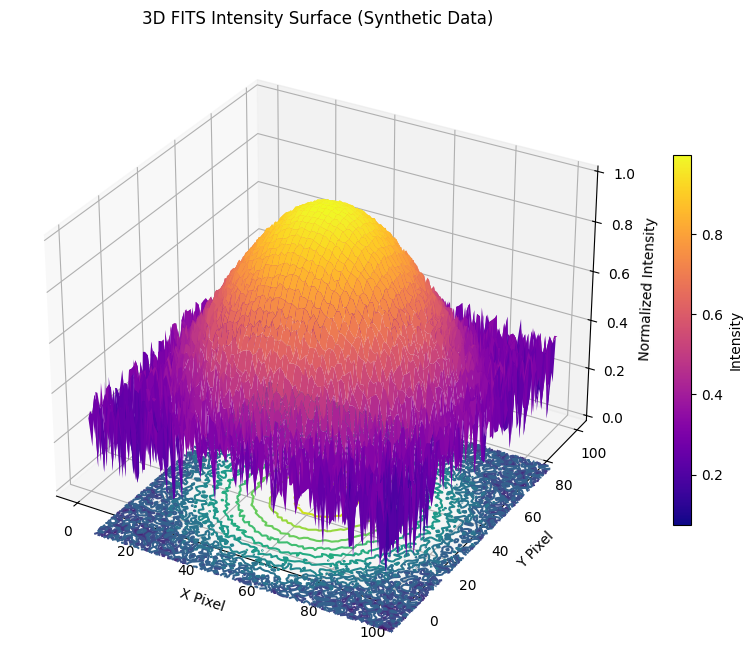

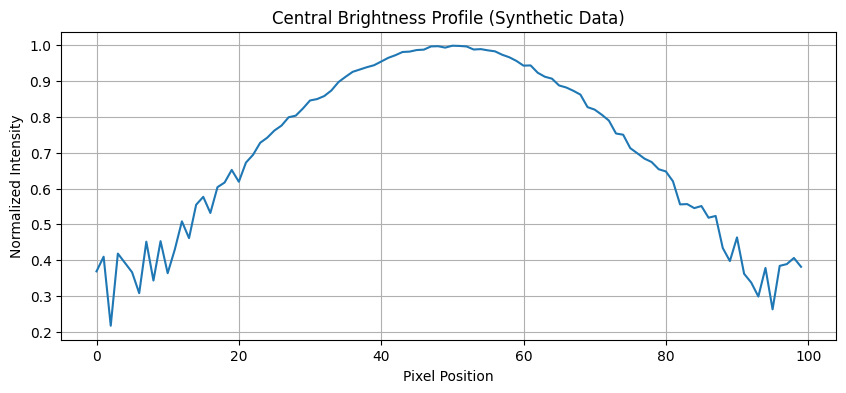

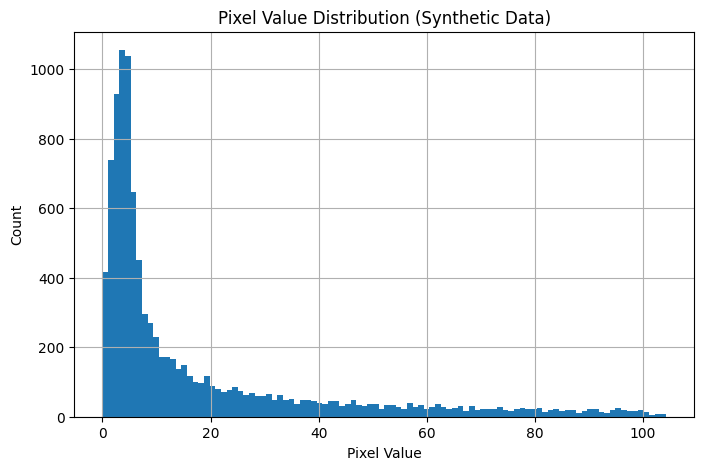

In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. FITS DOSYASINI OKU (veya sentetik veri oluştur)
# ==========================

# fits_file = "galaxy.fits"   # Eğer gerçek bir FITS dosyanız varsa bu satırı kullanın
# data = fits.getdata(fits_file)

# 'galaxy.fits' bulunamadığı için sentetik veri oluşturuluyor
# Örneğin, bir 2D Gauss fonksiyonu veya sinüs dalgası deseni
x_grid, y_grid = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
data = 100 * np.exp(-((x_grid**2 + y_grid**2) / 5)) + np.random.rand(100, 100) * 5 # Örnek sentetik veri

print("Shape :", data.shape)
print("Minimum :", np.min(data))
print("Maximum :", np.max(data))
print("Mean    :", np.mean(data))
print("Std Dev :", np.std(data))

# ==========================
# 2. LOGARİTMİK DÖNÜŞÜM
# ==========================

# Negative values in data can cause issues with log1p. Clamping to a small positive value.
data_positive = np.maximum(data, 1e-6) # Ensure all values are positive
data_log = np.log1p(data_positive)

# ==========================
# 3. NORMALİZASYON
# ==========================

data_norm = (
    data_log - data_log.min()
) / (
    data_log.max() - data_log.min()
)

# ==========================
# 4. KOORDİNATLAR
# ==========================

y, x = np.mgrid[
    0:data_norm.shape[0],
    0:data_norm.shape[1]
]

# ==========================
# 5. 3D INTENSITY SURFACE
# ==========================

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

surface = ax.plot_surface(
    x,
    y,
    data_norm,
    cmap="plasma",
    linewidth=0,
    antialiased=True
)

# Eş parlaklık eğrileri
ax.contour(
    x,
    y,
    data_norm,
    levels=15,
    offset=-0.2
)

ax.set_title(
    "3D FITS Intensity Surface (Synthetic Data)"
)

ax.set_xlabel(
    "X Pixel"
)

ax.set_ylabel(
    "Y Pixel"
)

ax.set_zlabel(
    "Normalized Intensity"
)

fig.colorbar(
    surface,
    shrink=0.6,
    label="Intensity"
)

plt.show()

# ==========================
# 6. MERKEZ PARLAKLIK PROFİLİ
# ==========================

center_y = data_norm.shape[0] // 2

profile = data_norm[
    center_y,
    :
]

plt.figure(figsize=(10,4))

plt.plot(profile)

plt.title(
    "Central Brightness Profile (Synthetic Data)"
)

plt.xlabel(
    "Pixel Position"
)

plt.ylabel(
    "Normalized Intensity"
)

plt.grid(True)

plt.show()

# ==========================
# 7. HISTOGRAM
# ==========================

plt.figure(figsize=(8,5))

plt.hist(
    data.flatten(),
    bins=100
)

plt.title(
    "Pixel Value Distribution (Synthetic Data)"
)

plt.xlabel(
    "Pixel Value"
)

plt.ylabel(
    "Count"
)

plt.grid(True)

plt.show()

In this project, I transformed astronomical FITS image data into a three-dimensional intensity surface. Each pixel's brightness value was mapped to a height coordinate, allowing the image to be visualized as a mathematical surface rather than a simple 2D picture. Logarithmic scaling and normalization were applied to enhance faint structures and reveal details across a wide dynamic range.

This approach makes it possible to study stars, galactic cores, and brightness distributions from a quantitative perspective. Additional analyses such as intensity histograms, contour mapping, and brightness profiles provide deeper insight into the physical structure of the observed object.

Tools used: Python, NumPy, Matplotlib, Astropy, and astronomical FITS data.
